In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
mice_protein_expression = fetch_ucirepo(id=342)

# data (as pandas dataframes)
X = mice_protein_expression.data.features
y = mice_protein_expression.data.targets

# metadata
print(mice_protein_expression.metadata)

# variable information
print(mice_protein_expression.variables)


{'uci_id': 342, 'name': 'Mice Protein Expression', 'repository_url': 'https://archive.ics.uci.edu/dataset/342/mice+protein+expression', 'data_url': 'https://archive.ics.uci.edu/static/public/342/data.csv', 'abstract': 'Expression levels of 77 proteins measured in the cerebral cortex of 8 classes of control and Down syndrome mice exposed to context fear conditioning, a task used to assess associative learning.', 'area': 'Biology', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 1080, 'num_features': 80, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': ['MouseID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Tue Apr 16 2024', 'dataset_doi': '10.24432/C50S3Z', 'creators': ['Clara Higuera', 'Katheleen Gardiner', 'Krzysztof Cios'], 'intro_paper': {'ID': 475, 'type': 'NATIVE', 'title': 'Self-Organizing Feature Maps Identify Proteins Critical

Поради тоа што целта на лабораториската е ненадгледувано учење, треба да ги
тргнете првиот и последните 4 атрибути, и да работите само со 77-те протеински
експресии и сами да пробате да ги најдете кластерите кои ги сугерираат класите.

In [7]:
# Протеините почнуваат од втората колона (индекс 1)
# и ги има точно 77. Значи одиме до индекс 78 (бидејќи 78 не е вклучен).
df_proteins = X.iloc[:, 1:77]

# Проверка
print(f"Колони во финалната табела: {df_proteins.shape[1]}")

Колони во финалната табела: 76


In [8]:
print(df_proteins.head())

    ITSN1_N    BDNF_N     NR1_N    NR2A_N    pAKT_N   pBRAF_N  pCAMKII_N  \
0  0.747193  0.430175  2.816329  5.990152  0.218830  0.177565   2.373744   
1  0.689064  0.411770  2.789514  5.685038  0.211636  0.172817   2.292150   
2  0.730247  0.418309  2.687201  5.622059  0.209011  0.175722   2.283337   
3  0.617076  0.358626  2.466947  4.979503  0.222886  0.176463   2.152301   
4  0.617430  0.358802  2.365785  4.718679  0.213106  0.173627   2.134014   

    pCREB_N    pELK_N    pERK_N  ...     SHH_N     BAD_N  BCL2_N     pS6_N  \
0  0.232224  1.750936  0.687906  ...  0.188852  0.122652     NaN  0.106305   
1  0.226972  1.596377  0.695006  ...  0.200404  0.116682     NaN  0.106592   
2  0.230247  1.561316  0.677348  ...  0.193685  0.118508     NaN  0.108303   
3  0.207004  1.595086  0.583277  ...  0.192112  0.132781     NaN  0.103184   
4  0.192158  1.504230  0.550960  ...  0.205604  0.129954     NaN  0.104784   

    pCFOS_N     SYP_N  H3AcK18_N    EGR1_N  H3MeK4_N    CaNA_N  
0  0.1083

2. Запознавање со податочното множество и претпроцесирање.
Визуелизирајте го податочното множество во 2 или 3 димензии користејќи PCA.

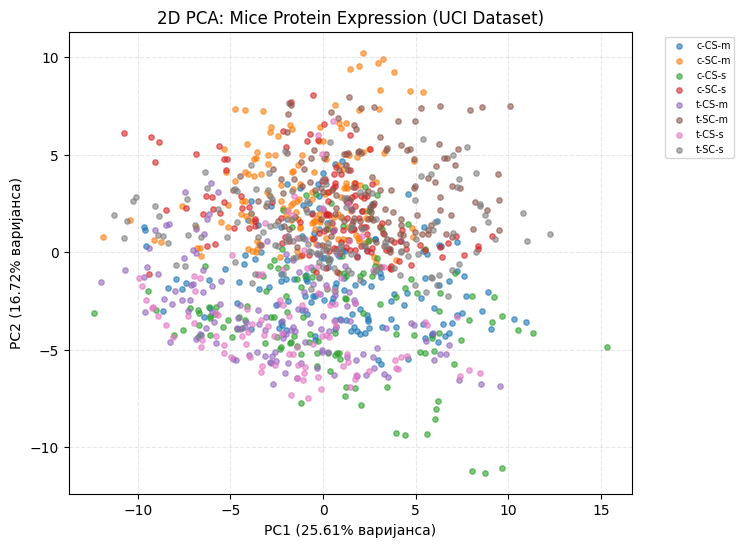

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from mpl_toolkits.mplot3d import Axes3D

# 2. Претпроцесирање (Импутација + Стандардизација)
# Справување со вредности што недостасуваат
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(df_proteins)

# Стандардизација (задолжително за PCA)
X_scaled = StandardScaler().fit_transform(X_imputed)

# 3. Креирање на фигура за визуелизација
fig = plt.figure(figsize=(16, 6))

# --- 2D PCA ---
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

ax1 = fig.add_subplot(121)
# Бидејќи y е DataFrame, користиме .iloc[:, 0] за да ги земеме класите како серија
target_names = y.iloc[:, 0].unique()

for name in target_names:
    indices = y.iloc[:, 0] == name
    ax1.scatter(X_pca_2d[indices, 0], X_pca_2d[indices, 1], label=name, alpha=0.6, s=15)

ax1.set_title('2D PCA: Mice Protein Expression (UCI Dataset)')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} варијанса)')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} варијанса)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
ax1.grid(True, linestyle='--', alpha=0.3)


3. Кластерирање.
Искористете 2 од методите за кластерирање кои ги имаме учено и видете кои се
резултатите кои се добиваат. Дали резултатите се слични?
a) Gaussian Mixture Models
b) K-Means
c) Hierarchical Clustering
d) DBSCAN

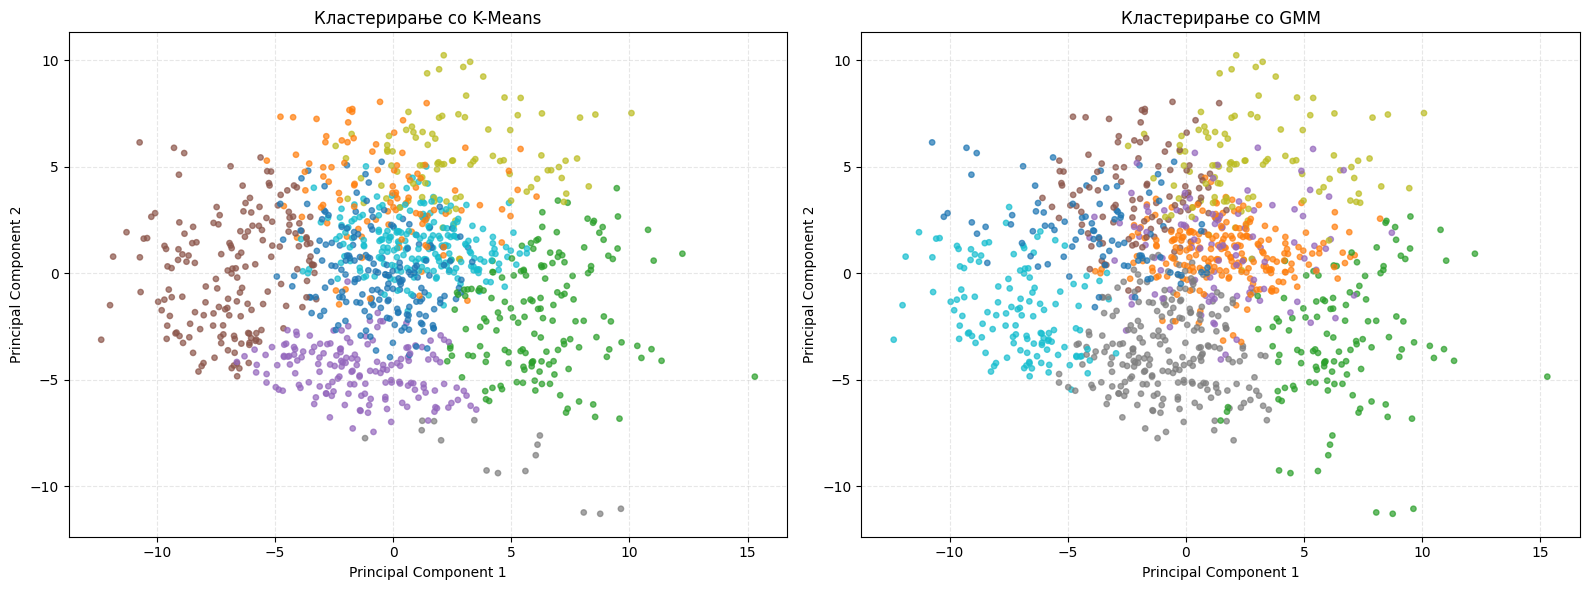

K-Means инерција: 47432.19
GMM Lower Bound (Log-likelihood): 4.84


In [14]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# 1. Имплементација на K-Means
# Користиме 8 кластери бидејќи толку класи постојат во Mice Protein податочното множество
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 2. Имплементација на GMM
# Користиме 'full' коваријанса за да овозможиме флексибилни, елипсоидни форми на кластерите
gmm = GaussianMixture(n_components=8, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# 3. Визуелизација и споредба на резултатите (користејќи ги веќе пресметаните X_pca_2d)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График за K-Means
scatter1 = ax1.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.7, s=15)
ax1.set_title('Кластерирање со K-Means')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True, linestyle='--', alpha=0.3)

# График за GMM
scatter2 = ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels, cmap='tab10', alpha=0.7, s=15)
ax2.set_title('Кластерирање со GMM')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Споредба на резултатите
print(f"K-Means инерција: {kmeans.inertia_:.2f}")
print(f"GMM Lower Bound (Log-likelihood): {gmm.lower_bound_:.2f}")

4. Визуелизација на резултатите.
Визуелизирајте ги резултатите во 2 или 3 димензии со една боја на секој кластер,
повторно користејќи некој од методите како PCA или t-SNE.

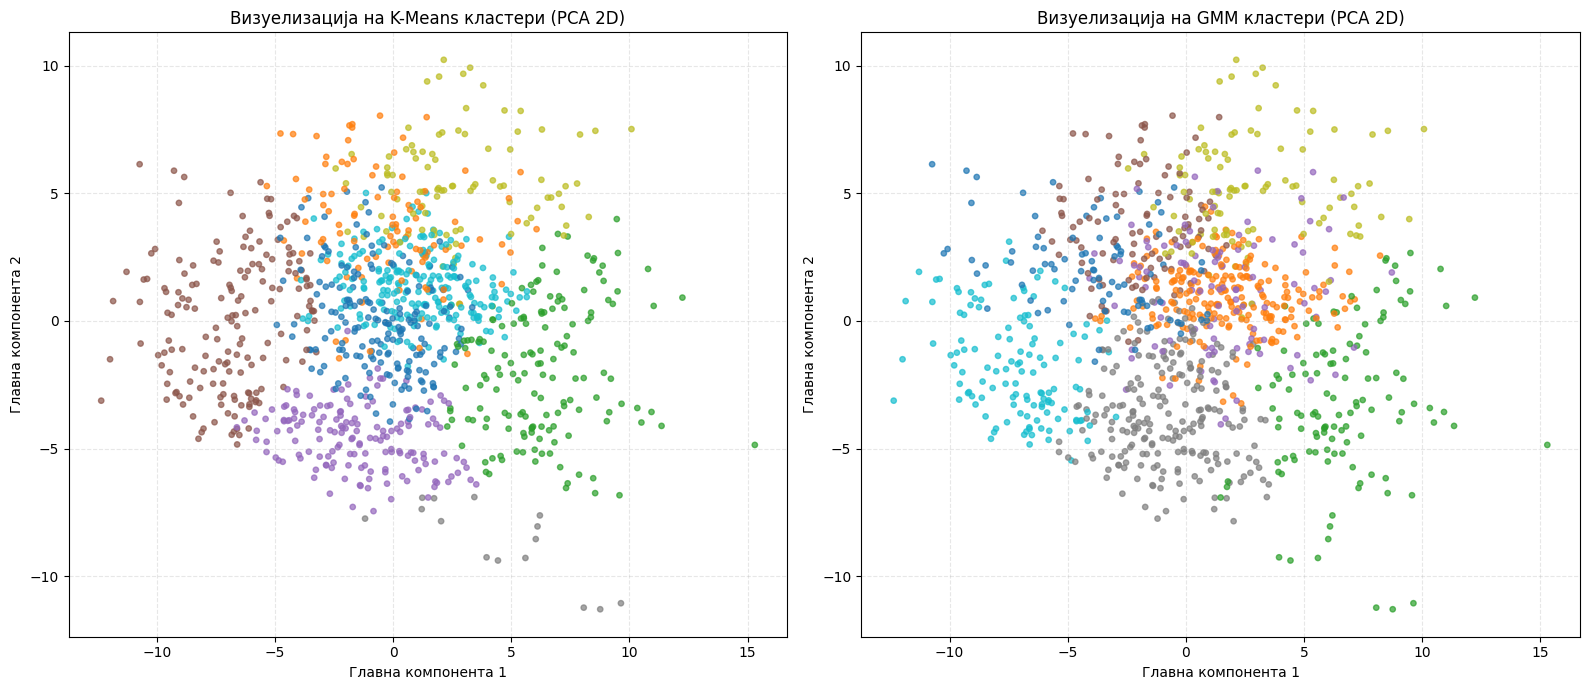

In [16]:
# Користиме 2D проекција од PCA за визуелизација на кластерите
plt.figure(figsize=(16, 7))

# 1. Приказ на K-Means резултатите
plt.subplot(1, 2, 1)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap='tab10', s=15, alpha=0.7)
plt.title('Визуелизација на K-Means кластери (PCA 2D)')
plt.xlabel('Главна компонента 1')
plt.ylabel('Главна компонента 2')
plt.grid(True, linestyle='--', alpha=0.3)

# 2. Приказ на GMM резултатите
plt.subplot(1, 2, 2)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels, cmap='tab10', s=15, alpha=0.7)
plt.title('Визуелизација на GMM кластери (PCA 2D)')
plt.xlabel('Главна компонента 1')
plt.ylabel('Главна компонента 2')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
from sklearn.metrics import adjusted_rand_score

# Пресметај колку се слични ознаките (1.0 значи дека се идентични)
similarity = adjusted_rand_score(kmeans_labels, gmm_labels)
print(f"Сличност помеѓу K-Means и GMM: {similarity:.4f}")

# Провери дали има барем една точка што е различно класифицирана
diff = np.sum(kmeans_labels != gmm_labels)
print(f"Број на точки со различна ознака: {diff} од вкупно {len(kmeans_labels)}")

Сличност помеѓу K-Means и GMM: 0.5086
Број на точки со различна ознака: 810 од вкупно 1080


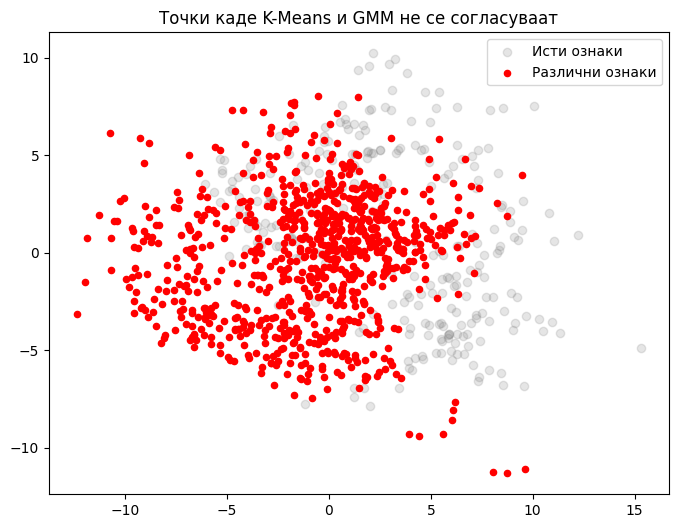

In [18]:
# Најди ги индексите каде ознаките се различни (внимавај на label switching)
# Ова е само за илустрација ако ознаките се веќе поредени
mismatch = kmeans_labels != gmm_labels

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[~mismatch, 0], X_pca_2d[~mismatch, 1], c='gray', alpha=0.2, label='Исти ознаки')
plt.scatter(X_pca_2d[mismatch, 0], X_pca_2d[mismatch, 1], c='red', s=20, label='Различни ознаки')
plt.title('Точки каде K-Means и GMM не се согласуваат')
plt.legend()
plt.show()